In this assignment you will build and audit a Convolutional Neural Network (CNN) for image classification

Key Learning Goals:       
* Load and normalize the CIFAR-10 dataset
  
* Build a CNN from scratch (Conv2D + MaxPooling)

* Train and diagnose learning behavior via loss/accuracy curves

* Probe intermediate **feature maps** to interpret what the CNN learns

*  Audit **parameter efficiency** vs a dense MLP baseline

## Task 1: Image Data Understanding & Preprocessing (20 points)



2026-02-28 21:15:26.843418: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 21:15:27.226248: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 21:15:28.529539: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/water/Grad School/DSE6212/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar

Train images: (50000, 32, 32, 3) Train labels: (50000, 1)
Test images: (10000, 32, 32, 3) Test labels: (10000, 1)
Example label integer: 6


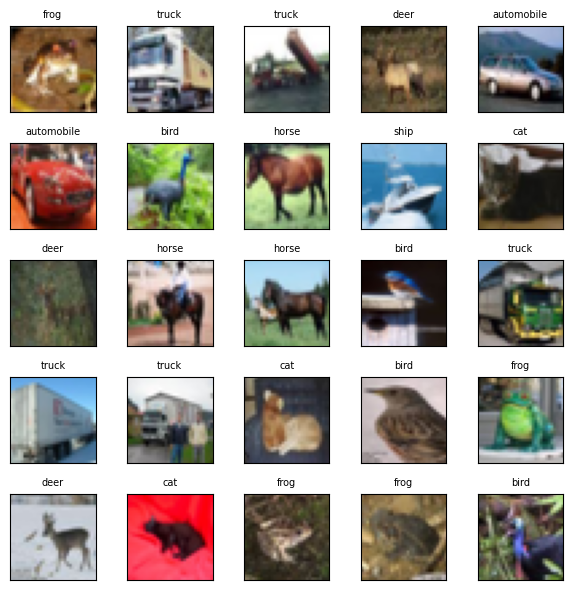

In [1]:
# ==================== Task 1: Dataset Preparation ====================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import datasets

SEED = 42
np.random.seed(SEED)

# Load CIFAR-10 data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixels (Divide by 255.0)
train_images = train_images.astype("float32") / 255.0   # e.g., 255.0
test_images  = test_images.astype("float32") / 255.0

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print("Train images:", train_images.shape, "Train labels:", train_labels.shape)
print("Test images:", test_images.shape, "Test labels:", test_labels.shape)
print("Example label integer:", train_labels[0][0])

# Quick sanity visualization
plt.figure(figsize=(6,6))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([])
    plt.imshow(train_images[i])
    plt.title(class_names[int(train_labels[i][0])], fontsize=7)
plt.tight_layout()
plt.show()

Question:

*  What is the tensor shape of one image? What do the dimensions represent?

**The tensor shape of an image is (32, 32, 3), representing a width and heighht of 32 pixels and 3 color channels.**

*  Why is normalization important for gradient-based training?

**Normalizing the image standardized the dynamic range, making the gradient and loss computation more robust across the dataset. If the images were not normalized to a 0-1 range, the topography of the loss landscape would be mostly flat with a few local minima, which the model would struggle to converge to without a perfect learning rate. Once normalized, the loss function topography becomes more standardized, with clear minima that can be reached from smoother gradients, making training far more reliable.**

*  Why would a fully connected network be inefficient for raw images?

**There are two reasons: first, the number of parameters required to train a fully connected network on image data scales exponentially with the input image size. Second, fully connected networks cannot extract spatial features from the image, making the relative position of a target object in the image a parameter for the classification. This makes deploying a production model nearly impossible, as the training data could not possibly contain all translational and rotational configurations of a variety of class types.**

## Task 2: Building CNN (20 Points)

In [2]:
## Student Code Required ##
# Instructions: Construct a Sequential model with at least two Conv2D layers.
# You must decide on the number of filters and
# the padding strategy ('same' vs. 'valid')

# ==================== Task 2: Custom CNN Architecture Construction ====================

import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(SEED)

# Architecture choices
num_classes = 10  # should be 10

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # choose filters, kernel size, padding
    layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    layers.MaxPooling2D((2,2)),

    # Optional: add a third conv block (leave blank if not used)
    layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(32*32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

I0000 00:00:1772331331.971882     881 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,135,498 (4.33 MB)

 Trainable params: 1,135,498 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

Question:

*   Which layers learn spatial features? Which layers perform classification?

**Spatial features are learned via the Conv2D and MaxPooling2D layers. The Conv2D layers apply various filters, in this case 64, to the input to detect different patterns such as vertical edges, horizontal edges, textures, and shapes. MaxPooling2D reduces the dimensionality while preserving the features derived from the Conv2D layers. Classification is handled by the dense layers at the end of the model, which is receiving a flattened representation of the image, hence the 32*32 parameter count. The extracted features from the convolutional and pooling layers map the dense layer input to class probabilities.**

*   What does pooling accomplish in terms of spatial information and robustness?

**Pooling reduces the height and width of the features output from the convolutional layer, such as 32 x 32 down to 16 x 16. This reduces the number of parameters and makes the model more computationally efficient. Pooling makes the network more robust by selecting the maximum value on a local region (2 x 2 in this case), which manifests as a slight compression and blurring of the input. This makes the model more robust to small distortions, rotations, or translations in the input image, as the max of a local region will likely remain the same when the model is fed the same feature type.**

## Task 3: Intermediate Activation Visualization (30 Points)

In [3]:
## Student Code Required ##
# Create a sub-model that outputs the feature maps of your
# first convolutional layer.
# This is how you 'audit' what the model is actually learning

## ==================== Task 3A: Compile + Train ====================

# Training hyperparameters
EPOCHS = 10 #(Recommended: 10)
BATCH  = 64 #(Recommended: 64)
LR     = 1e-3 #(Recommended: 1e -3)

# Sparse labels setup
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

Epoch 1/10


2026-02-28 21:15:34.035084: I external/local_xla/xla/service/service.cc:163] XLA service 0x75a5fc017a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-28 21:15:34.035105: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2026-02-28 21:15:34.058987: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-28 21:15:34.181499: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


 67/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1683 - loss: 2.2083

I0000 00:00:1772331336.451452    7362 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


607/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3605 - loss: 1.7427

2026-02-28 21:15:38.161213: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 4 bytes spill stores, 4 bytes spill loads

2026-02-28 21:15:39.003912: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 8 bytes spill stores, 8 bytes spill loads

2026-02-28 21:15:39.007801: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 4 bytes spill stores, 4 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4613 - loss: 1.4848 - val_accuracy: 0.5850 - val_loss: 1.1508
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6190 - loss: 1.0666 - val_accuracy: 0.6555 - val_loss: 0.9597
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6896 - loss: 0.8860 - val_accuracy: 0.6974 - val_loss: 0.8616
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7327 - loss: 0.7585 - val_accuracy: 0.7188 - val_loss: 0.8064
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7659 - loss: 0.6609 - val_accuracy: 0.7231 - val_loss: 0.8188
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7970 - loss: 0.5774 - val_accuracy: 0.7229 - val_loss: 0.8258
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8214 - loss: 0.5062 - val_accuracy: 0.7017 - val_loss: 0.9442
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8409 - loss: 0.4546 - val_accuracy: 0.7108 - val_

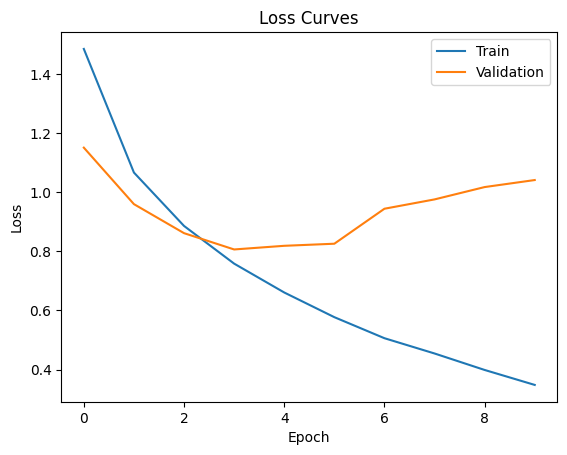

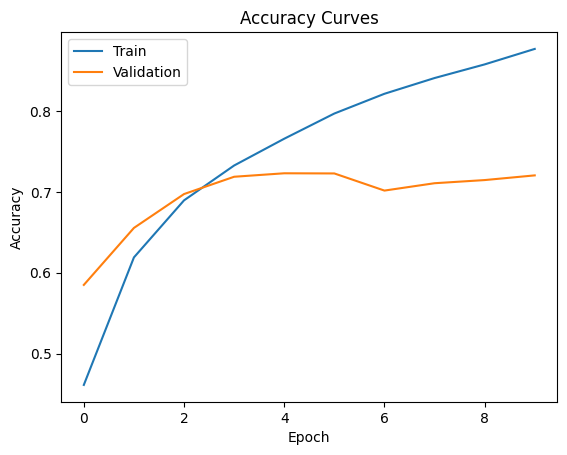

In [4]:
# ==================== Task 3B: Learning Curves ====================


import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.title("Loss Curves")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("Accuracy Curves")
plt.show()

In [5]:
# ==================== Task 3C: Test Evaluation ====================

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print("Test accuracy:", test_acc)

2026-02-28 21:15:54.012142: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 16 bytes spill stores, 16 bytes spill loads

2026-02-28 21:15:54.055317: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 4 bytes spill stores, 4 bytes spill loads



Test accuracy: 0.7204999923706055


Question:

*  Do the curves show overfitting? Cite evidence from loss/accuracy curves.

**Yes, the curves do show overfitting as there is a divergence between train and validation, as well as training and validation accuracy, starting around epoch 2.**

*  If overfitting is present, name two changes you would try and why.

**The most beneficial change would be the amount of data present to train with. The dataset, in this use case, is of a fixed size, but augmentation could be used to add more variation to the input data so the model has more features to learn. Additionally, a higher dropout percentage and more dropout layers could be used to randomly disable more neurons in the model, forcing them to be more adaptable to variance across multiple images of the same class (i.e. eliminating the possibility for a specific neuron to only be mapped to the eye of the dog class, but instead mapped to an eye feature that is only present in classes that contain eyes).**

## Task 4: Feature Map Visualization (15 Points)

In [10]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Conv2D name=conv2d_2, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


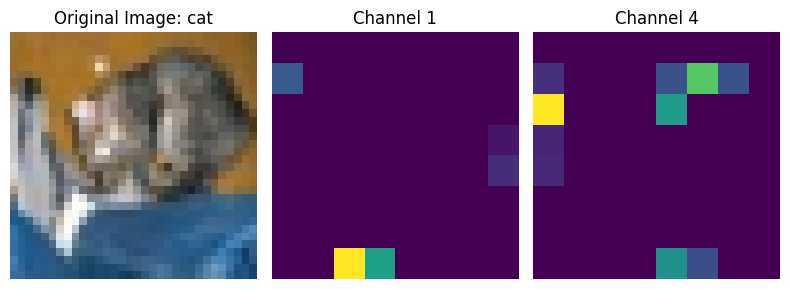

In [41]:
# ==================== Task 4A: Feature Map Audit ====================

from tensorflow.keras import models

# Cchoose a Conv2D layer index to probe
# Tip: print model.layers to identify Conv2D layers.
LAYER_INDEX = 4

# Do this to make the model callable so the activation instantiation works properly
sample = test_images[0:1]
model(sample)  

activation_model = models.Model(
    inputs=model.inputs,
    outputs=model.layers[LAYER_INDEX].output
)

activations = activation_model.predict(sample)   # shape: (1, H, W, C)

# Choose channels to visualize
ch1, ch2 = 1, 4

plt.figure(figsize=(8,4))
plt.subplot(1,3,1); plt.imshow(test_images[0:1][0]); plt.title(f"Original Image: {class_names[test_labels[0][0]]}"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(activations[0,:,:,ch1]); plt.title(f"Channel {ch1}"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(activations[0,:,:,ch2]); plt.title(f"Channel {ch2}"); plt.axis("off")
plt.tight_layout()
plt.show()

Layer 1 Feature Maps:


/tmp/ipykernel_881/4262991428.py:16: RuntimeWarning: invalid value encountered in divide
  channel_image /= channel_image.std()
/tmp/ipykernel_881/4262991428.py:19: RuntimeWarning: invalid value encountered in cast
  channel_image = np.clip(channel_image, 0, 255).astype('uint8')


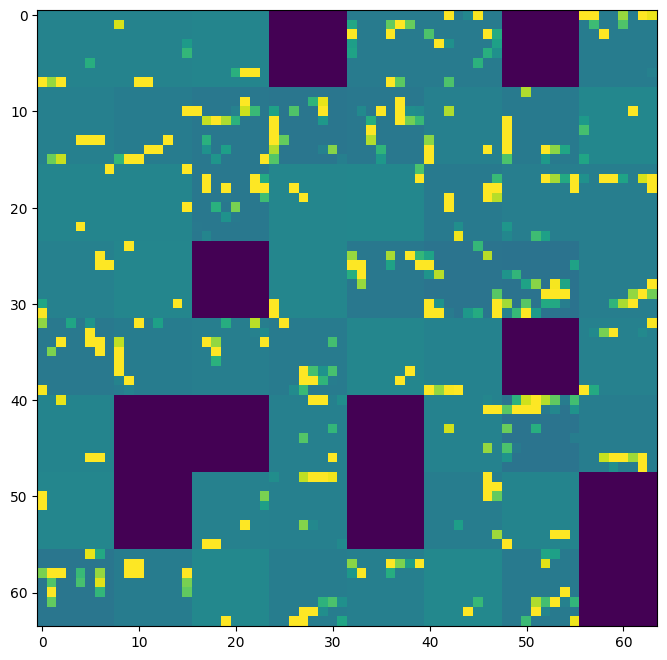

In [42]:
# ==================== Helper: Grid Visualization ====================
# Use this to see ALL filters in a layer to find the "Cat Ear"
import math

def visualize_layer(layer_output, images_per_row=8):
    n_features = layer_output.shape[-1] # Number of features in the feature map
    size = layer_output.shape[1] # The feature map has shape (1, size, size, n_features)
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_output[0, :, :, col * images_per_row + row]
            # Post-process the feature to make it visually palatable
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()

# Visualize the first layer (Edges)
print("Layer 1 Feature Maps:")
visualize_layer(activations) # Assuming 'activations' is your output from the code above

Question: The "Cat Ear" Trace

**Don't just look for "blurry blobs." Look for Hierarchical Learning.**

In a CNN, early layers act as "Edge Detectors," while deeper layers act as "Object Detectors."

**Task: Feature Tracing**
1.  **Layer 1 (The Edge):** Look at the grid of filters from your first Convolutional layer. Identify one specific filter index (e.g., #7) that seems to activate strongly on **diagonal lines** or **textures**.

**Filter 57 appears to activate strongly on diagonal lines.**

2.  **Layer 2/3 (The Object):** Change the `LAYER_INDEX` in the code above to point to your *last* Convolutional layer. Run the visualization again.
    * Can you find a filter that activates specifically on the **"ear" region** or the **"face" region** of the cat?

**Filter 23 of layer index 4 appears to activate on the face region of the cat.**


**Critical Thinking:**
If you *cannot* find a filter that clearly isolates the "cat ear" in the final layer, what does that tell you about the depth of your model?
* *Hint:* Is a 2-layer or 3-layer CNN deep enough to combine "edges" into "ears," or is it only seeing "textures"?


## Task 5: Parameter Efficiency Audit (15 points)

In [33]:
# ==================== Task 5: Parameter Efficiency Audit ====================

# CNN parameters
cnn_params = model.count_params()
print("CNN parameters:", cnn_params)

# MLP estimate on raw 32x32x3 input
input_dim = 32 * 32 * 3

# Cchoose a hidden width for comparison
hidden = 32*32   # e.g., 100

mlp_params = (input_dim * hidden + hidden) + (hidden * 10 + 10)
print("MLP parameters (1 hidden layer):", mlp_params)
print("MLP / CNN parameter ratio:", mlp_params / cnn_params)

CNN parameters: 1135498
MLP parameters (1 hidden layer): 3157002
MLP / CNN parameter ratio: 2.780279665838249


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,406,496 (12.99 MB)

 Trainable params: 1,135,498 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,270,998 (8.66 MB)

Question:

*   Why does a CNN use fewer parameters than an MLP on the same input?

**CNNs reduced the dimensionality of the image with each pass of a convolutional filter. The image may begin as a 32 x 32 x 3 dimensional vector, but when passed through a 2D convolutional layer with a 3x3 kernel, a stride of 1, and no padding, the output is "compressed" to a 30 x 30 x FILTER_COUNT matrix. Most importantly, the CNN layers are not fully connected layers, but instead feed the larger dimensional image layers into the smaller, filtered output, reducing the required number of parameters.**

*   Relate your parameter audit to convolution’s “weight sharing.”

**The convolutional layer utilizes a 3x3 kernel to compute the layer output, which generates one shared weight for all 9 pixels in the kernel. A fully connected MLP model would require 9 weights to process the same region of image data, resulting in 9x the number of parameters.**


## Optional for week 8

In [43]:
# ==================== Optional Export for Week 8 Comparison ====================

import json

week7_summary = {
    "cnn_test_accuracy": float(test_acc),
    "cnn_params": int(cnn_params),
    "mlp_params": int(mlp_params)
}

with open("week7_cnn_baseline.json", "w") as f:
    json.dump(week7_summary, f, indent=2)

print("Saved week7_cnn_baseline.json for Week 8 comparison.")

Saved week7_cnn_baseline.json for Week 8 comparison.
